## How to Train YOLOv8 Object Detection on a Custom Dataset

In [ ]:
!nvidia-smi

Wed Dec  4 15:41:01 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              10W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.5/898.5 kB 45.1 MB/s eta 0:00:00


## Install YOLOv8

In [ ]:
from ultralytics import YOLO
import os
from IPython.display import display, Image
from IPython import display
display.clear_output()
!yolo mode=checks

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
  File "/usr/local/lib/python3.10/dist-packages/ultralytics/cfg/__init__.py", line 911, in entrypoint
    raise ValueError(f"Invalid 'mode={mode}'. Valid modes are {MODES}.\n{CLI_HELP_MSG}")
ValueError: Invalid 'mode=<module 'ultralytics.utils.checks' from '/usr/local/lib/python3.10/dist-packages/ultralytics/utils/checks.py'>'. Valid modes are {'predict', 'export', 'train', 'benchmark', 'track', 'val'}.

    Arguments received: ['yolo', 'mode=checks']. Ultralytics 'yolo' commands use the following syntax:

        yolo TASK MODE ARGS

        Where   TASK (optional) is one of {'obb', 'segment', 'classify', 'pose', 'detect'}
                MODE (required) is one of {'predict', 'export', 'train', 'benchmark', 'track', 'val'}
                ARGS (optional) are any number of custom 'arg=value' pairs like 'imgsz=320' that override defaults.
                    See all ARGS at ht

## Train YOLOv8 Model on Custom Dataset

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="##################")
project = rf.workspace("rupiah").project("antonius-fhilifi_50420202_remed-dm")
version = project.version(1)
dataset = version.download("yolov8")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Antonius-Fhilifi_50420202_Remed-DM-1 in yolov8:: 100%|██████████| 5612/5612 [00:00<00:00, 7045.94it/s]


In [ ]:
!yolo task=detect mode=train model=yolov8m.pt data={dataset.location}/data.yaml epochs=15 imgsz=640

100% 49.7M/49.7M [00:00<00:00, 305MB/s]
Ultralytics 8.3.40 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/content/Antonius-Fhilifi_50420202_Remed-DM-1/data.yaml, epochs=15, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf

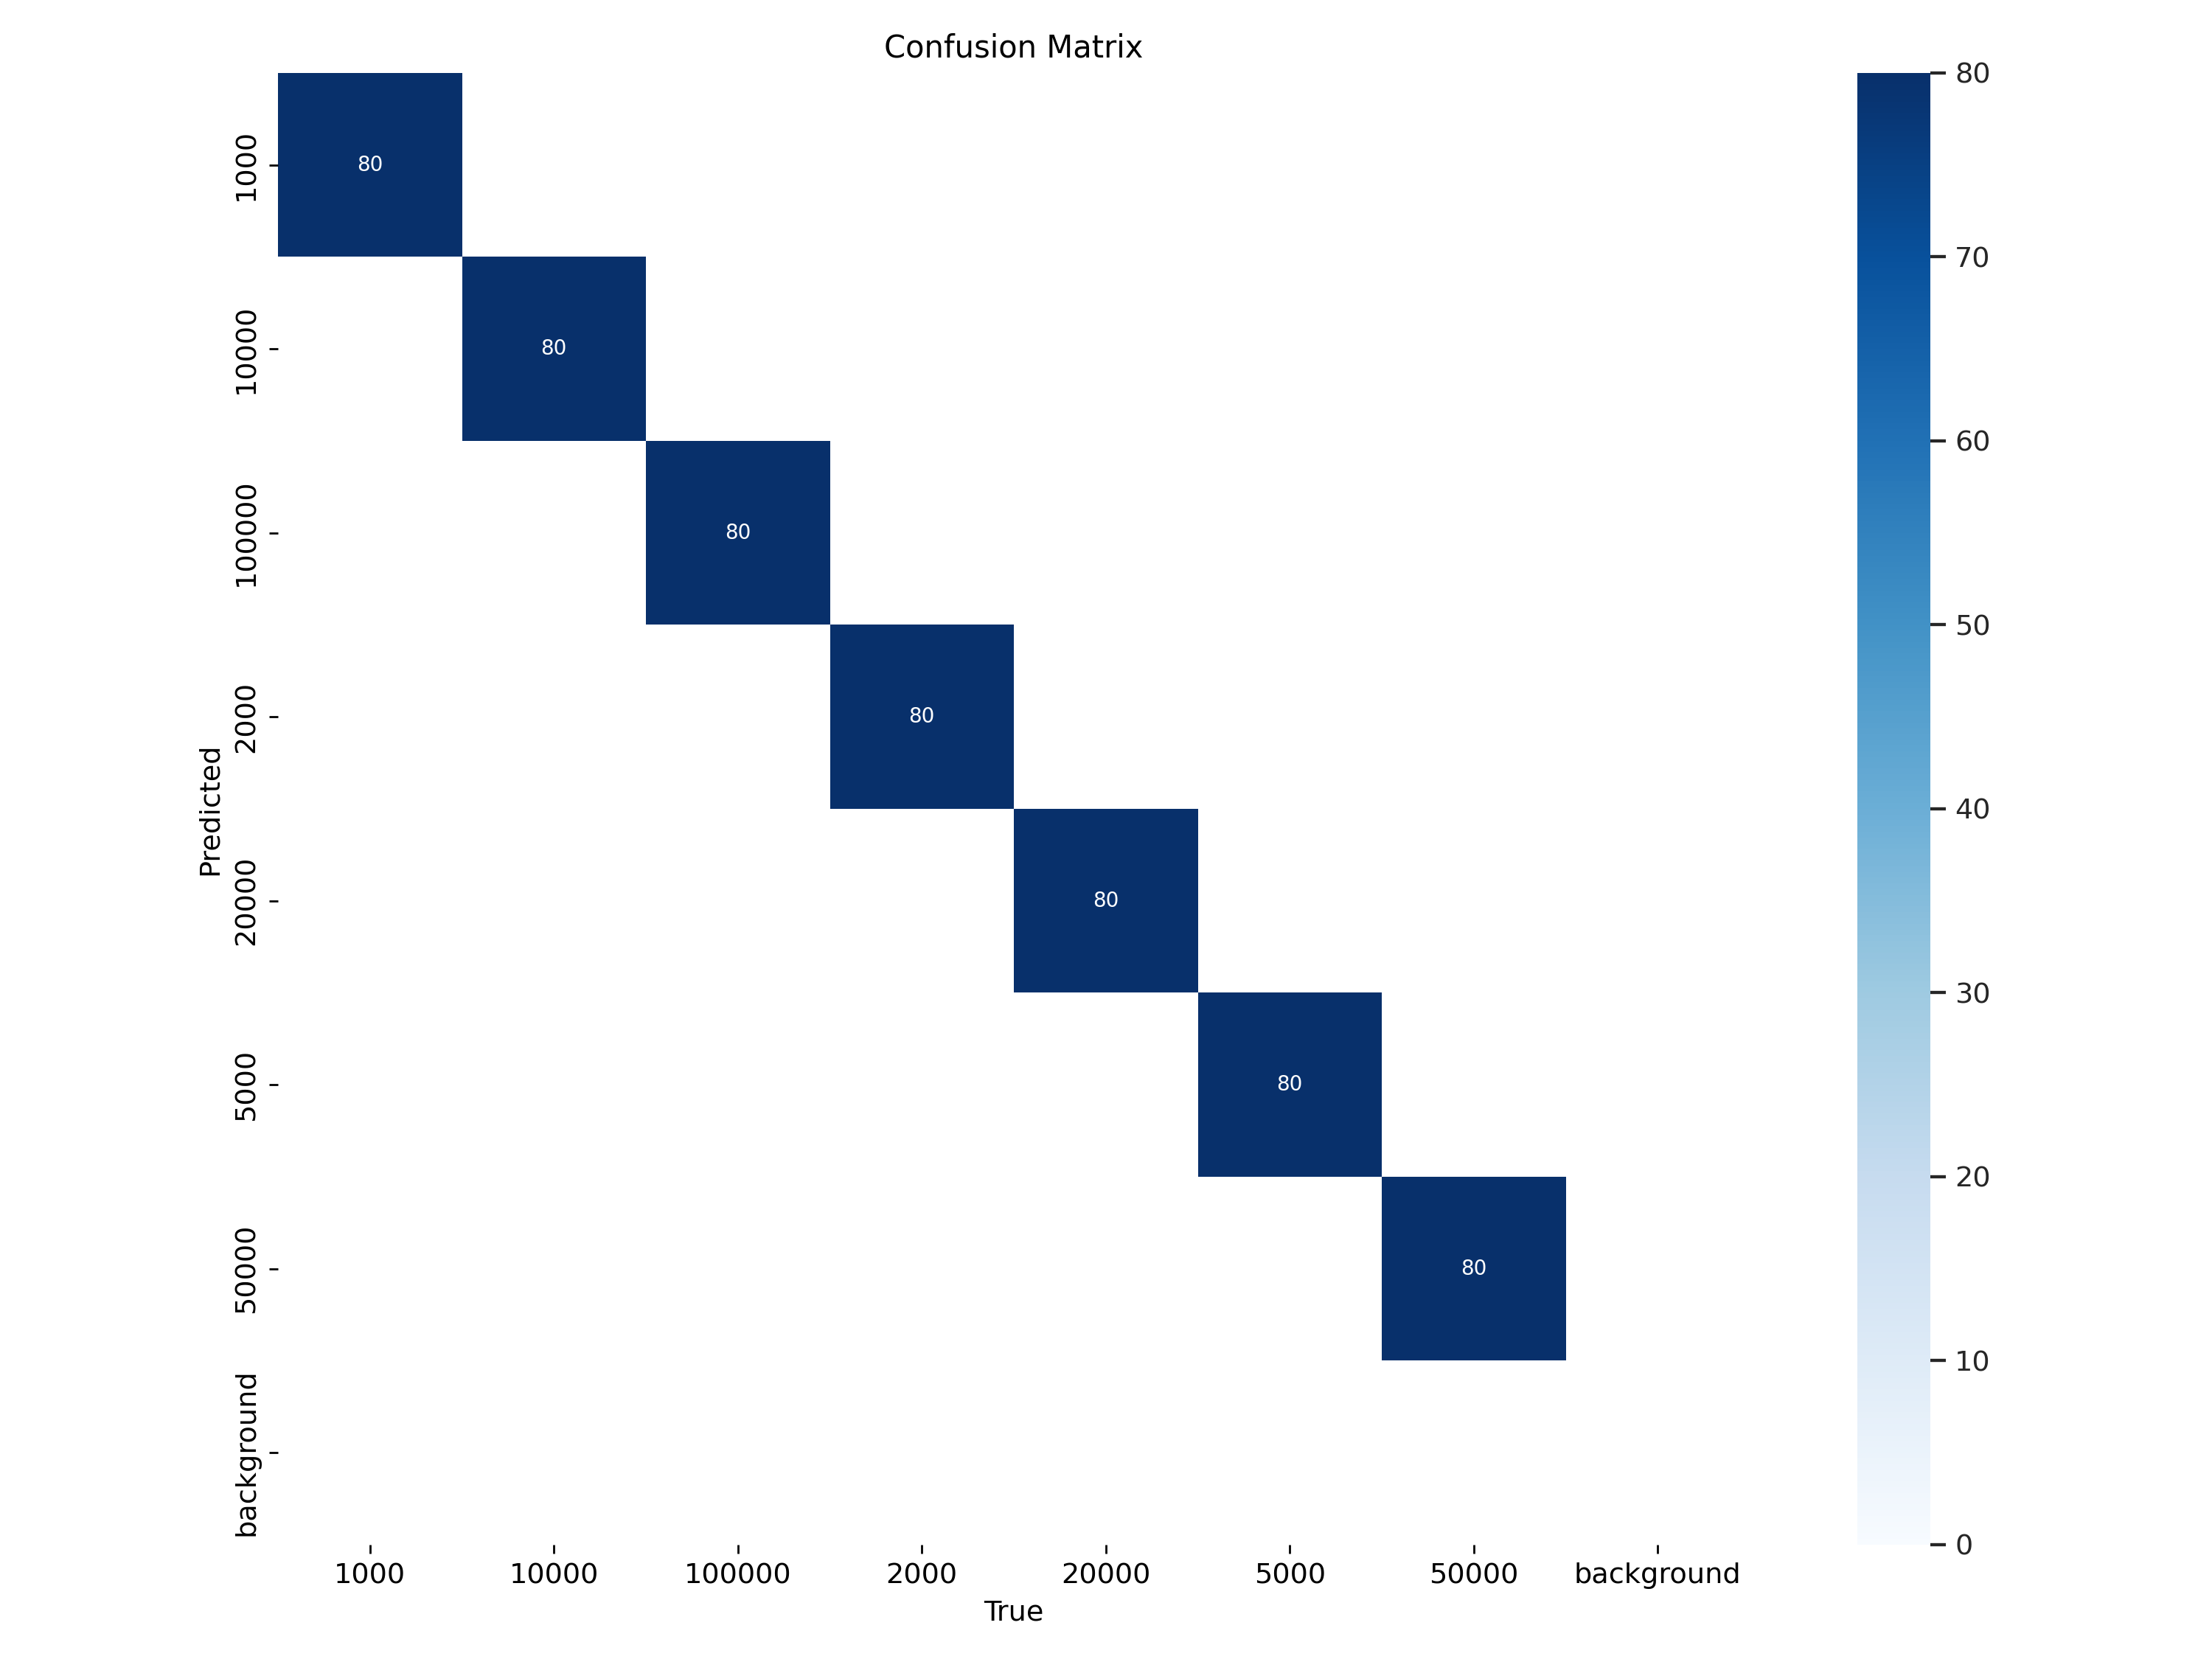

In [ ]:
Image(filename=f'/content/runs/detect/train/confusion_matrix.png', width=600)

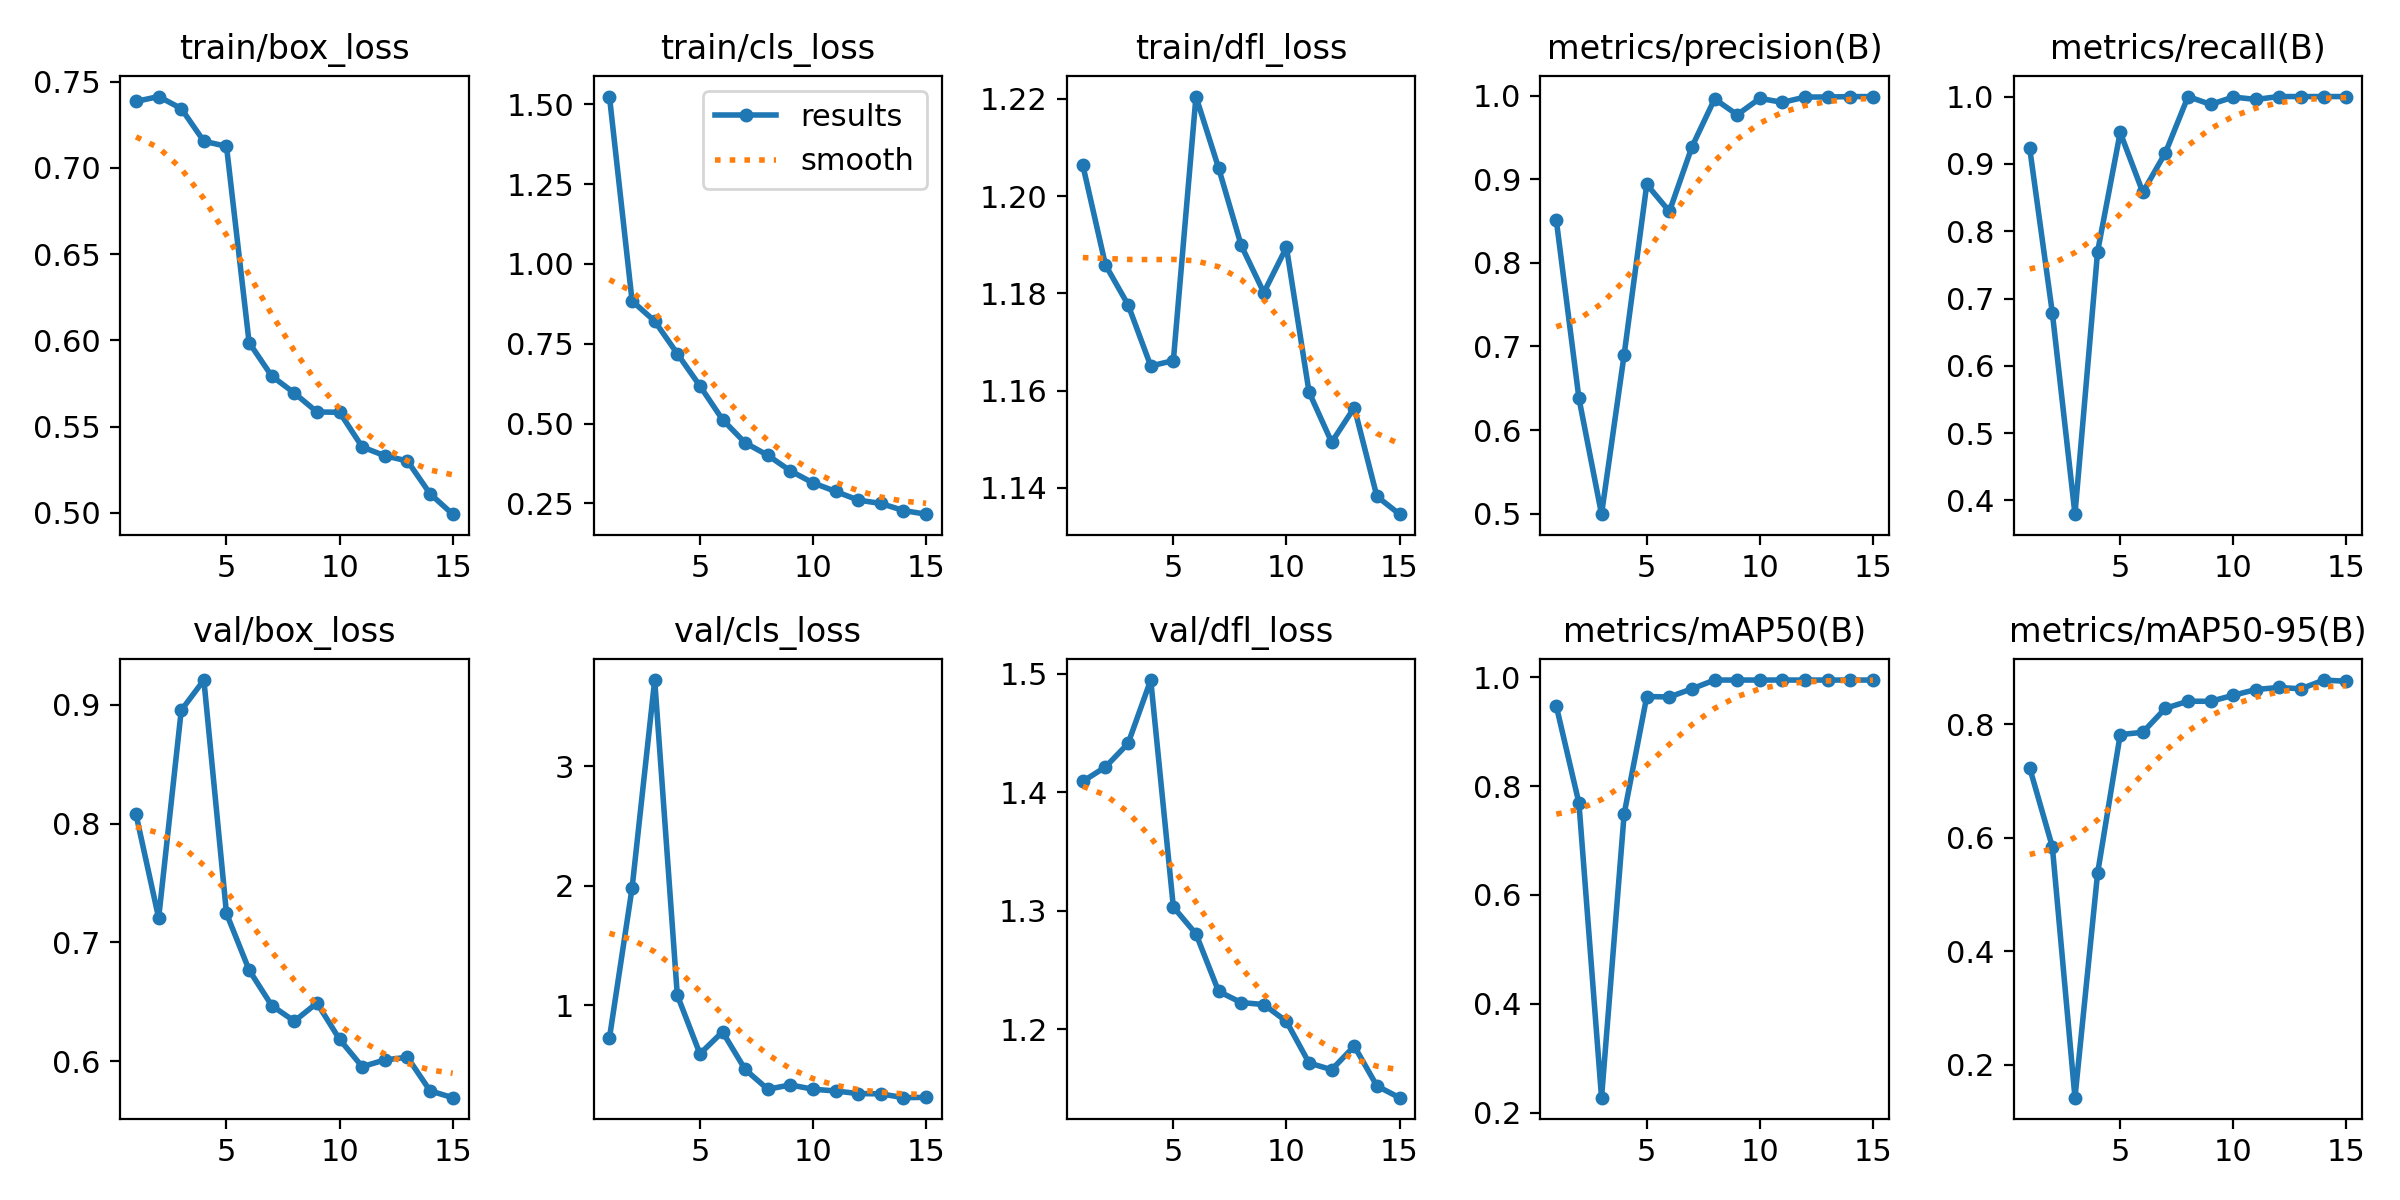

In [ ]:
Image(filename=f'/content/runs/detect/train/results.png', width=600)

In [ ]:
!yolo task=detect mode=val model=/content/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.40 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 218 layers, 25,843,813 parameters, 0 gradients, 78.7 GFLOPs
val: Scanning /content/Antonius-Fhilifi_50420202_Remed-DM-1/valid/labels.cache... 560 images, 0 backgrounds, 0 corrupt: 100% 560/560 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 35/35 [00:15<00:00,  2.20it/s]
                   all        560        560      0.999          1      0.995      0.878
                  1000         80         80      0.999          1      0.995      0.884
                 10000         80         80      0.999          1      0.995      0.887
                100000         80         80      0.999          1      0.995      0.771
                  2000         80         80      0.999          1      0.995      0.899
                 20000         80         80      0.998          1      0.995      0.948
                  5000   

In [ ]:
!yolo task=detect mode=predict model=/content/runs/detect/train/weights/best.pt conf=0.5 source={dataset.location}/test/images save_txt=true save_conf=true

Ultralytics 8.3.40 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 218 layers, 25,843,813 parameters, 0 gradients, 78.7 GFLOPs

image 1/280 /content/Antonius-Fhilifi_50420202_Remed-DM-1/test/images/0_jpg.rf.8cef4b8faf996c519f67f54f455127aa.jpg: 640x640 1 2000, 37.1ms
image 2/280 /content/Antonius-Fhilifi_50420202_Remed-DM-1/test/images/0_jpg.rf.e5991221b77f01a01b3dee40ab68639b.jpg: 640x640 1 5000, 37.2ms
image 3/280 /content/Antonius-Fhilifi_50420202_Remed-DM-1/test/images/1009_jpg.rf.7c7233371feb2e7ff56b8b4a6c6b4467.jpg: 640x640 1 1000, 37.2ms
image 4/280 /content/Antonius-Fhilifi_50420202_Remed-DM-1/test/images/100_jpg.rf.5747e9d21f67ae5b8f1ce0d37392d83b.jpg: 640x640 1 10000, 37.1ms
image 5/280 /content/Antonius-Fhilifi_50420202_Remed-DM-1/test/images/101_jpg.rf.948a0bf03d3b005ff859a5555b0eca54.jpg: 640x640 1 5000, 37.1ms
image 6/280 /content/Antonius-Fhilifi_50420202_Remed-DM-1/test/images/102-Copy_jpg.rf.7109be6bb62e932f5b81c3d8059ff56a.jpg: 64

In [ ]:
import glob
from IPython.display import Image, display

for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg'):
      display(Image(filename=image_path, height=600))
      print("\n")